# **교통 데이터: 지리 데이터 시각화**

## **데이터 살펴보기**

[서울 열린데이터 광장](http://data.seoul.go.kr/dataList/OA-12252/S/1/datasetView.do)

In [55]:
import pandas as pd
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [56]:
data = pd.read_csv(r'c:\Users\1\Desktop\데이터분석 공부\ryang_python_practice\part.3\Data\실습5_ 교통 데이터를 활용한 지리 데이터 시각화\서울시 지하철 호선별 역별 시간대별 승하차 인원 정보.csv', encoding='cp949')

In [57]:
data.head()

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자
0,202307,1호선,동대문,710,31,11581,2095,9027,6829,14177,...,8930,511,2412,0,216,0,0,0,0,20230803
1,202307,1호선,동묘앞,221,2,3012,1090,3682,5042,7336,...,4195,104,1649,0,272,0,0,0,0,20230803
2,202307,1호선,서울역,577,37,8434,9396,13088,51243,40143,...,13987,2297,2598,1,219,0,0,0,0,20230803
3,202307,1호선,시청,49,5,2381,4825,3784,22736,7558,...,4285,287,1085,0,12,0,0,0,0,20230803
4,202307,1호선,신설동,392,35,8967,2356,9520,8509,21822,...,9505,317,2244,0,0,0,0,0,0,20230803


- 서울시 지하철 승하차인원의 월별 합계

- 2018년 이후, 2호선만, 승차 인원만 분석 예정

## **질문 만들기**

- 승차 인원이 가장 많은 역은?
- 연도별로 혹은 월별로 승차 인원 추이에 차이가 있는가?
- 시간대별로 가장 승차인원이 많은 역은?
- 지하철역 시간대별 인원 유형 군집화
- 지도에 분석 결과를 시각화하기

## **데이터 전처리**

- 날짜 컬럼 추가

In [58]:
data['연도'] = pd.to_datetime(data['사용월'], format='%Y%m').dt.year
data['월'] = pd.to_datetime(data['사용월'], format='%Y%m').dt.month

data.head()

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자,연도,월
0,202307,1호선,동대문,710,31,11581,2095,9027,6829,14177,...,2412,0,216,0,0,0,0,20230803,2023,7
1,202307,1호선,동묘앞,221,2,3012,1090,3682,5042,7336,...,1649,0,272,0,0,0,0,20230803,2023,7
2,202307,1호선,서울역,577,37,8434,9396,13088,51243,40143,...,2598,1,219,0,0,0,0,20230803,2023,7
3,202307,1호선,시청,49,5,2381,4825,3784,22736,7558,...,1085,0,12,0,0,0,0,20230803,2023,7
4,202307,1호선,신설동,392,35,8967,2356,9520,8509,21822,...,2244,0,0,0,0,0,0,20230803,2023,7


- 2018년 이후, 2호선만 필터링

In [59]:
data = data.query('호선명 == "2호선" and 연도 >= 2018')

In [60]:
data

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자,연도,월
10,202307,2호선,강남,120,14,9359,10930,18503,56268,40112,...,6609,3,47,0,0,0,0,20230803,2023,7
11,202307,2호선,강변(동서울터미널),27,1,8936,2251,28877,21987,78164,...,5412,1,39,0,0,0,0,20230803,2023,7
12,202307,2호선,건대입구,290,1,16965,1813,22074,15573,53127,...,10526,3,862,0,0,0,0,20230803,2023,7
13,202307,2호선,교대(법원.검찰청),15,0,2693,6957,11535,25054,25250,...,3275,2,15,0,0,0,0,20230803,2023,7
14,202307,2호선,구로디지털단지,369,39,38505,5472,53882,20639,144838,...,14233,6,308,0,0,0,0,20230803,2023,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39852,201801,2호선,종합운동장,16,1,5482,1666,8502,11616,23624,...,3206,7,143,2,2,0,0,20180203,2018,1
39853,201801,2호선,충정로(경기대입구),35,19,3435,1114,7825,6722,18950,...,2910,1,82,0,0,0,0,20180203,2018,1
39854,201801,2호선,한양대,19,11,1252,471,2634,5582,6349,...,1361,2,24,0,0,0,0,20180203,2018,1
39855,201801,2호선,합정,152,52,10582,3237,18773,18726,50049,...,8398,1,278,0,0,0,0,20180203,2018,1


- 지하철역명 통일

In [61]:
sorted(data['지하철역'].unique())

['강남',
 '강변(동서울터미널)',
 '건대입구',
 '교대(법원.검찰청)',
 '구로디지털단지',
 '구의(광진구청)',
 '낙성대',
 '낙성대(강감찬)',
 '당산',
 '대림(구로구청)',
 '도림천',
 '동대문역사문화공원',
 '동대문역사문화공원(DDP)',
 '뚝섬',
 '문래',
 '방배',
 '봉천',
 '사당',
 '삼성(무역센터)',
 '상왕십리',
 '서울대입구(관악구청)',
 '서초',
 '선릉',
 '성수',
 '시청',
 '신답',
 '신당',
 '신대방',
 '신도림',
 '신림',
 '신설동',
 '신정네거리',
 '신촌',
 '아현',
 '양천구청',
 '역삼',
 '영등포구청',
 '왕십리(성동구청)',
 '용답',
 '용두(동대문구청)',
 '을지로3가',
 '을지로4가',
 '을지로입구',
 '이대',
 '잠실(송파구청)',
 '잠실나루',
 '잠실새내',
 '종합운동장',
 '충정로(경기대입구)',
 '한양대',
 '합정',
 '홍대입구']

In [62]:
list(data['지하철역'].str.split('('))

[['강남'],
 ['강변', '동서울터미널)'],
 ['건대입구'],
 ['교대', '법원.검찰청)'],
 ['구로디지털단지'],
 ['구의', '광진구청)'],
 ['낙성대', '강감찬)'],
 ['당산'],
 ['대림', '구로구청)'],
 ['도림천'],
 ['동대문역사문화공원', 'DDP)'],
 ['뚝섬'],
 ['문래'],
 ['방배'],
 ['봉천'],
 ['사당'],
 ['삼성', '무역센터)'],
 ['상왕십리'],
 ['서울대입구', '관악구청)'],
 ['서초'],
 ['선릉'],
 ['성수'],
 ['시청'],
 ['신답'],
 ['신당'],
 ['신대방'],
 ['신도림'],
 ['신림'],
 ['신설동'],
 ['신정네거리'],
 ['신촌'],
 ['아현'],
 ['양천구청'],
 ['역삼'],
 ['영등포구청'],
 ['왕십리', '성동구청)'],
 ['용답'],
 ['용두', '동대문구청)'],
 ['을지로3가'],
 ['을지로4가'],
 ['을지로입구'],
 ['이대'],
 ['잠실', '송파구청)'],
 ['잠실나루'],
 ['잠실새내'],
 ['종합운동장'],
 ['충정로', '경기대입구)'],
 ['한양대'],
 ['합정'],
 ['홍대입구'],
 ['강남'],
 ['강변', '동서울터미널)'],
 ['건대입구'],
 ['교대', '법원.검찰청)'],
 ['구로디지털단지'],
 ['구의', '광진구청)'],
 ['낙성대', '강감찬)'],
 ['당산'],
 ['대림', '구로구청)'],
 ['도림천'],
 ['동대문역사문화공원', 'DDP)'],
 ['뚝섬'],
 ['문래'],
 ['방배'],
 ['봉천'],
 ['사당'],
 ['삼성', '무역센터)'],
 ['상왕십리'],
 ['서울대입구', '관악구청)'],
 ['서초'],
 ['선릉'],
 ['성수'],
 ['시청'],
 ['신답'],
 ['신당'],
 ['신대방'],
 ['신도림'],
 ['신림'],
 ['신설동'],
 ['신정네거리'],
 ['신촌'],
 ['아현

In [63]:
data['지하철역'] = [i[0] for i in data['지하철역'].str.split('(')]  ## 괄호를 기준으로 자르고 앞에 하나만 꺼낸다
sorted(data['지하철역'].unique())

['강남',
 '강변',
 '건대입구',
 '교대',
 '구로디지털단지',
 '구의',
 '낙성대',
 '당산',
 '대림',
 '도림천',
 '동대문역사문화공원',
 '뚝섬',
 '문래',
 '방배',
 '봉천',
 '사당',
 '삼성',
 '상왕십리',
 '서울대입구',
 '서초',
 '선릉',
 '성수',
 '시청',
 '신답',
 '신당',
 '신대방',
 '신도림',
 '신림',
 '신설동',
 '신정네거리',
 '신촌',
 '아현',
 '양천구청',
 '역삼',
 '영등포구청',
 '왕십리',
 '용답',
 '용두',
 '을지로3가',
 '을지로4가',
 '을지로입구',
 '이대',
 '잠실',
 '잠실나루',
 '잠실새내',
 '종합운동장',
 '충정로',
 '한양대',
 '합정',
 '홍대입구']

- 승차 인원만 추출하기

In [64]:
on_col = [i for i in data.columns if '승차' in i]
on_col

['04시-05시 승차인원',
 '05시-06시 승차인원',
 '06시-07시 승차인원',
 '07시-08시 승차인원',
 '08시-09시 승차인원',
 '09시-10시 승차인원',
 '10시-11시 승차인원',
 '11시-12시 승차인원',
 '12시-13시 승차인원',
 '13시-14시 승차인원',
 '14시-15시 승차인원',
 '15시-16시 승차인원',
 '16시-17시 승차인원',
 '17시-18시 승차인원',
 '18시-19시 승차인원',
 '19시-20시 승차인원',
 '20시-21시 승차인원',
 '21시-22시 승차인원',
 '22시-23시 승차인원',
 '23시-24시 승차인원',
 '00시-01시 승차인원',
 '01시-02시 승차인원',
 '02시-03시 승차인원',
 '03시-04시 승차인원']

In [65]:
on_col = [i for i in data.columns if '승차' in i]
data = data[['사용월','연도','월','지하철역']+on_col]  ## 컬럼명 가져오기

data.head()

,사용월,연도,월,지하철역,04시-05시 승차인원,05시-06시 승차인원,06시-07시 승차인원,07시-08시 승차인원,08시-09시 승차인원,09시-10시 승차인원,...,18시-19시 승차인원,19시-20시 승차인원,20시-21시 승차인원,21시-22시 승차인원,22시-23시 승차인원,23시-24시 승차인원,00시-01시 승차인원,01시-02시 승차인원,02시-03시 승차인원,03시-04시 승차인원
10,202307,2023,7,강남,120,9359,18503,40112,64256,52713,...,327480,215011,172551,196756,177694,80992,13773,3,0,0
11,202307,2023,7,강변,27,8936,28877,78164,117728,82763,...,61291,43557,32792,27539,19267,7874,1058,1,0,0
12,202307,2023,7,건대입구,290,16965,22074,53127,91248,61438,...,85337,64419,65838,72636,74202,45555,7559,3,0,0
13,202307,2023,7,교대,15,2693,11535,25250,36820,27461,...,133358,62654,51239,53658,42819,15754,3171,2,0,0
14,202307,2023,7,구로디지털단지,369,38505,53882,144838,184498,112257,...,210532,101581,65184,55202,41572,18845,3463,6,0,0


## **분석**

### [1] 승차 인원이 가장 많은 역은?

- 합계 컬럼 만들기

In [66]:
data['합계'] = data[on_col].sum(axis=1)  ## 행의 합계 컬럼 추가

data.head()

,사용월,연도,월,지하철역,04시-05시 승차인원,05시-06시 승차인원,06시-07시 승차인원,07시-08시 승차인원,08시-09시 승차인원,09시-10시 승차인원,...,19시-20시 승차인원,20시-21시 승차인원,21시-22시 승차인원,22시-23시 승차인원,23시-24시 승차인원,00시-01시 승차인원,01시-02시 승차인원,02시-03시 승차인원,03시-04시 승차인원,합계
10,202307,2023,7,강남,120,9359,18503,40112,64256,52713,...,215011,172551,196756,177694,80992,13773,3,0,0,2408376
11,202307,2023,7,강변,27,8936,28877,78164,117728,82763,...,43557,32792,27539,19267,7874,1058,1,0,0,933338
12,202307,2023,7,건대입구,290,16965,22074,53127,91248,61438,...,64419,65838,72636,74202,45555,7559,3,0,0,1060476
13,202307,2023,7,교대,15,2693,11535,25250,36820,27461,...,62654,51239,53658,42819,15754,3171,2,0,0,852909
14,202307,2023,7,구로디지털단지,369,38505,53882,144838,184498,112257,...,101581,65184,55202,41572,18845,3463,6,0,0,1629379


- 지하철역별 월평균 승차 인원 구하기

In [67]:
data_mean = data.groupby('지하철역')[['합계']].mean().reset_index().rename({'합계':'월평균'}, axis=1).sort_values('월평균', ascending=False)  ## 내림차순 정렬
data_mean

,지하철역,월평균
0,강남,2.475218e+06
42,잠실,2.185502e+06
49,홍대입구,1.895644e+06
27,신림,1.815902e+06
4,구로디지털단지,1.656332e+06
16,삼성,1.496685e+06
26,신도림,1.481450e+06
20,선릉,1.463946e+06
18,서울대입구,1.390678e+06
33,역삼,1.286969e+06


In [68]:
fig = px.bar(data_frame = data_mean, x='지하철역', y='월평균', title='지하철역별 월평균 승차인원')
fig.show()

### [2] 연도별로 혹은 월별로 승차 인원 추이에 차이가 있는가?

In [69]:
data.head()

,사용월,연도,월,지하철역,04시-05시 승차인원,05시-06시 승차인원,06시-07시 승차인원,07시-08시 승차인원,08시-09시 승차인원,09시-10시 승차인원,...,19시-20시 승차인원,20시-21시 승차인원,21시-22시 승차인원,22시-23시 승차인원,23시-24시 승차인원,00시-01시 승차인원,01시-02시 승차인원,02시-03시 승차인원,03시-04시 승차인원,합계
10,202307,2023,7,강남,120,9359,18503,40112,64256,52713,...,215011,172551,196756,177694,80992,13773,3,0,0,2408376
11,202307,2023,7,강변,27,8936,28877,78164,117728,82763,...,43557,32792,27539,19267,7874,1058,1,0,0,933338
12,202307,2023,7,건대입구,290,16965,22074,53127,91248,61438,...,64419,65838,72636,74202,45555,7559,3,0,0,1060476
13,202307,2023,7,교대,15,2693,11535,25250,36820,27461,...,62654,51239,53658,42819,15754,3171,2,0,0,852909
14,202307,2023,7,구로디지털단지,369,38505,53882,144838,184498,112257,...,101581,65184,55202,41572,18845,3463,6,0,0,1629379


In [70]:
year_sum = data.query('연도 <= 2022').groupby(['연도'])[['합계']].sum().reset_index()
year_sum['연도'] = year_sum['연도'].astype(str)

fig = px.line(data_frame=year_sum, x='연도', y='합계')
fig.show()

In [71]:
month_sum = data.query('연도 <= 2022').groupby(['월'])[['합계']].sum().reset_index()
month_sum['월'] = month_sum['월'].astype(str)

fig = px.line(data_frame=month_sum, x='월', y='합계')
fig.show()

### [3] 시간대별로 가장 승차인원이 많은 역은?

In [72]:
top10 = data_mean.sort_values('월평균', ascending=False).head(10)['지하철역']
top10

0          강남
42         잠실
49       홍대입구
27         신림
4     구로디지털단지
16         삼성
26        신도림
20         선릉
18      서울대입구
33         역삼
Name: 지하철역, dtype: object

In [73]:
data.query('지하철역 in @top10')

,사용월,연도,월,지하철역,04시-05시 승차인원,05시-06시 승차인원,06시-07시 승차인원,07시-08시 승차인원,08시-09시 승차인원,09시-10시 승차인원,...,19시-20시 승차인원,20시-21시 승차인원,21시-22시 승차인원,22시-23시 승차인원,23시-24시 승차인원,00시-01시 승차인원,01시-02시 승차인원,02시-03시 승차인원,03시-04시 승차인원,합계
10,202307,2023,7,강남,120,9359,18503,40112,64256,52713,...,215011,172551,196756,177694,80992,13773,3,0,0,2408376
14,202307,2023,7,구로디지털단지,369,38505,53882,144838,184498,112257,...,101581,65184,55202,41572,18845,3463,6,0,0,1629379
26,202307,2023,7,삼성,134,4731,6953,14095,19430,21335,...,167097,134943,113092,71095,19601,2882,0,0,0,1682910
28,202307,2023,7,서울대입구,4939,28307,44564,130432,174419,119622,...,52653,45652,46823,41750,21507,3663,0,0,0,1347604
30,202307,2023,7,선릉,147,4987,11730,21383,32954,34057,...,150314,95246,92475,80317,27789,4146,2,0,0,1573805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39833,201801,2018,1,신도림,2636,36606,56496,155047,164820,100303,...,108039,90028,90299,72408,37623,3453,10,2,0,1799862
39834,201801,2018,1,신림,271,42102,78085,236467,355318,200757,...,81828,64517,63698,60259,34782,5621,3,0,0,2119319
39840,201801,2018,1,역삼,93,4450,9836,16613,28147,27063,...,176768,103411,108748,77074,40618,5557,1,0,0,1508034
39849,201801,2018,1,잠실,188,15089,49570,144183,210774,147037,...,212270,187307,161958,127417,41228,5018,5,0,0,2696556


In [74]:
top10_mean_hour = data.query('지하철역 in @top10').groupby('지하철역')[on_col].mean()
top10_mean_hour

,04시-05시 승차인원,05시-06시 승차인원,06시-07시 승차인원,07시-08시 승차인원,08시-09시 승차인원,09시-10시 승차인원,10시-11시 승차인원,11시-12시 승차인원,12시-13시 승차인원,13시-14시 승차인원,...,18시-19시 승차인원,19시-20시 승차인원,20시-21시 승차인원,21시-22시 승차인원,22시-23시 승차인원,23시-24시 승차인원,00시-01시 승차인원,01시-02시 승차인원,02시-03시 승차인원,03시-04시 승차인원
지하철역,,,,,,,,,,,,,,,,,,,,,
강남,199.761194,11267.805970,20091.656716,40044.029851,64827.731343,54185.761194,54050.656716,72620.477612,92869.746269,115656.552239,...,343752.835821,223735.164179,178879.910448,216217.447761,207535.313433,83942.656716,12218.492537,41.925373,10.014925,0.626866
구로디지털단지,251.492537,39288.597015,52406.089552,137133.253731,182999.328358,115665.313433,68659.567164,61427.626866,66485.970149,68082.552239,...,223309.611940,115340.179104,69854.582090,60133.388060,46033.656716,19676.313433,2521.895522,11.776119,1.343284,0.119403
삼성,165.776119,4758.522388,7508.895522,15993.925373,21927.223881,22378.268657,24176.477612,35510.402985,45498.417910,60130.477612,...,294941.119403,168624.970149,123201.343284,105947.029851,71970.358209,19138.029851,2394.388060,59.761194,29.626866,0.552239
서울대입구,4147.731343,28407.373134,42981.582090,125993.507463,180685.805970,119475.805970,68434.402985,61263.716418,66588.074627,71341.164179,...,95358.582090,59846.805970,50127.925373,52080.597015,46056.686567,21462.447761,2779.701493,10.223881,2.283582,0.208955
선릉,102.313433,4914.492537,11078.328358,21083.328358,32790.985075,31822.820896,34649.179104,45507.268657,53924.343284,63801.223881,...,283547.059701,143360.208955,89939.089552,91230.776119,73719.223881,25119.850746,3186.000000,10.343284,2.298507,0.179104
신도림,3361.597015,35786.268657,50420.179104,134114.179104,140965.089552,89916.074627,61494.925373,60289.582090,68699.716418,72645.552239,...,134345.716418,81201.895522,68743.791045,70103.014925,52677.746269,21723.238806,2043.597015,15.716418,1.597015,0.119403
신림,284.044776,39889.641791,75300.283582,204526.492537,305087.701493,182738.835821,98890.149254,82922.119403,87595.701493,84726.820896,...,93013.238806,63213.104478,52872.417910,51414.462687,45214.208955,22744.761194,3191.626866,18.194030,2.238806,0.268657
역삼,44.149254,3807.164179,8615.835821,14899.805970,25531.537313,23781.820896,24348.492537,32903.552239,40367.059701,49070.597015,...,274455.746269,141883.850746,83333.000000,84076.910448,58585.552239,21395.791045,2791.358209,5.835821,1.208955,0.104478
잠실,92.358209,12148.671642,46134.417910,115525.567164,166209.074627,120828.656716,81041.298507,81278.716418,90041.104478,100344.522388,...,231972.447761,159950.358209,157380.462687,137989.805970,100085.656716,30282.104478,3182.029851,24.805970,2.179104,0.104478


In [75]:
top10_mean_hour.columns

Index(['04시-05시 승차인원', '05시-06시 승차인원', '06시-07시 승차인원', '07시-08시 승차인원',
       '08시-09시 승차인원', '09시-10시 승차인원', '10시-11시 승차인원', '11시-12시 승차인원',
       '12시-13시 승차인원', '13시-14시 승차인원', '14시-15시 승차인원', '15시-16시 승차인원',
       '16시-17시 승차인원', '17시-18시 승차인원', '18시-19시 승차인원', '19시-20시 승차인원',
       '20시-21시 승차인원', '21시-22시 승차인원', '22시-23시 승차인원', '23시-24시 승차인원',
       '00시-01시 승차인원', '01시-02시 승차인원', '02시-03시 승차인원', '03시-04시 승차인원'],
      dtype='object')

In [76]:
[i[:3] for i in top10_mean_hour.columns]

['04시',
 '05시',
 '06시',
 '07시',
 '08시',
 '09시',
 '10시',
 '11시',
 '12시',
 '13시',
 '14시',
 '15시',
 '16시',
 '17시',
 '18시',
 '19시',
 '20시',
 '21시',
 '22시',
 '23시',
 '00시',
 '01시',
 '02시',
 '03시']

In [77]:
top10_mean_hour.columns = [i[:3] for i in top10_mean_hour.columns]
top10_mean_hour.columns

Index(['04시', '05시', '06시', '07시', '08시', '09시', '10시', '11시', '12시', '13시',
       '14시', '15시', '16시', '17시', '18시', '19시', '20시', '21시', '22시', '23시',
       '00시', '01시', '02시', '03시'],
      dtype='object')

In [78]:
#주요 역 10개만 필터링하여 시간당 월평균 인원수 구하기
top10 = data_mean.sort_values('월평균', ascending=False).head(10)['지하철역']
top10_mean_hour = data.query('지하철역 in @top10').groupby('지하철역')[on_col].mean()
top10_mean_hour.columns = [i[:3] for i in top10_mean_hour.columns]
top10_mean_hour

,04시,05시,06시,07시,08시,09시,10시,11시,12시,13시,...,18시,19시,20시,21시,22시,23시,00시,01시,02시,03시
지하철역,,,,,,,,,,,,,,,,,,,,,
강남,199.761194,11267.805970,20091.656716,40044.029851,64827.731343,54185.761194,54050.656716,72620.477612,92869.746269,115656.552239,...,343752.835821,223735.164179,178879.910448,216217.447761,207535.313433,83942.656716,12218.492537,41.925373,10.014925,0.626866
구로디지털단지,251.492537,39288.597015,52406.089552,137133.253731,182999.328358,115665.313433,68659.567164,61427.626866,66485.970149,68082.552239,...,223309.611940,115340.179104,69854.582090,60133.388060,46033.656716,19676.313433,2521.895522,11.776119,1.343284,0.119403
삼성,165.776119,4758.522388,7508.895522,15993.925373,21927.223881,22378.268657,24176.477612,35510.402985,45498.417910,60130.477612,...,294941.119403,168624.970149,123201.343284,105947.029851,71970.358209,19138.029851,2394.388060,59.761194,29.626866,0.552239
서울대입구,4147.731343,28407.373134,42981.582090,125993.507463,180685.805970,119475.805970,68434.402985,61263.716418,66588.074627,71341.164179,...,95358.582090,59846.805970,50127.925373,52080.597015,46056.686567,21462.447761,2779.701493,10.223881,2.283582,0.208955
선릉,102.313433,4914.492537,11078.328358,21083.328358,32790.985075,31822.820896,34649.179104,45507.268657,53924.343284,63801.223881,...,283547.059701,143360.208955,89939.089552,91230.776119,73719.223881,25119.850746,3186.000000,10.343284,2.298507,0.179104
신도림,3361.597015,35786.268657,50420.179104,134114.179104,140965.089552,89916.074627,61494.925373,60289.582090,68699.716418,72645.552239,...,134345.716418,81201.895522,68743.791045,70103.014925,52677.746269,21723.238806,2043.597015,15.716418,1.597015,0.119403
신림,284.044776,39889.641791,75300.283582,204526.492537,305087.701493,182738.835821,98890.149254,82922.119403,87595.701493,84726.820896,...,93013.238806,63213.104478,52872.417910,51414.462687,45214.208955,22744.761194,3191.626866,18.194030,2.238806,0.268657
역삼,44.149254,3807.164179,8615.835821,14899.805970,25531.537313,23781.820896,24348.492537,32903.552239,40367.059701,49070.597015,...,274455.746269,141883.850746,83333.000000,84076.910448,58585.552239,21395.791045,2791.358209,5.835821,1.208955,0.104478
잠실,92.358209,12148.671642,46134.417910,115525.567164,166209.074627,120828.656716,81041.298507,81278.716418,90041.104478,100344.522388,...,231972.447761,159950.358209,157380.462687,137989.805970,100085.656716,30282.104478,3182.029851,24.805970,2.179104,0.104478


In [79]:
#전체 기준 히트맵
top10_mean_hour.style.background_gradient(cmap='pink_r', axis=None).format('{:.0f}')  ## axis=none은 전체를 가지고 그린다는 뜻

,04시,05시,06시,07시,08시,09시,10시,11시,12시,13시,14시,15시,16시,17시,18시,19시,20시,21시,22시,23시,00시,01시,02시,03시
지하철역,,,,,,,,,,,,,,,,,,,,,,,,
강남,200,11268,20092,40044,64828,54186,54051,72620,92870,115657,122541,149213,170881,240434,343753,223735,178880,216217,207535,83943,12218,42,10,1
구로디지털단지,251,39289,52406,137133,182999,115665,68660,61428,66486,68083,61964,64823,77632,122631,223310,115340,69855,60133,46034,19676,2522,12,1,0
삼성,166,4759,7509,15994,21927,22378,24176,35510,45498,60130,74138,94213,115663,188316,294941,168625,123201,105947,71970,19138,2394,60,30,1
서울대입구,4148,28407,42982,125994,180686,119476,68434,61264,66588,71341,64633,68216,75435,85348,95359,59847,50128,52081,46057,21462,2780,10,2,0
선릉,102,4914,11078,21083,32791,31823,34649,45507,53924,63801,72065,90514,121775,169803,283547,143360,89939,91231,73719,25120,3186,10,2,0
신도림,3362,35786,50420,134114,140965,89916,61495,60290,68700,72646,72069,75747,83664,101420,134346,81202,68744,70103,52678,21723,2044,16,2,0
신림,284,39890,75300,204526,305088,182739,98890,82922,87596,84727,76579,75055,81788,88834,93013,63213,52872,51414,45214,22745,3192,18,2,0
역삼,44,3807,8616,14900,25532,23782,24348,32904,40367,49071,56615,73720,92117,174617,274456,141884,83333,84077,58586,21396,2791,6,1,0
잠실,92,12149,46134,115526,166209,120829,81041,81279,90041,100345,105703,121147,142022,182116,231972,159950,157380,137990,100086,30282,3182,25,2,0


In [80]:
#행 기준 히트맵
top10_mean_hour.style.background_gradient(cmap='pink_r', axis=1).format('{:.0f}')  ## axis = 1은 행기준. 행 중에서 클수록 진한색

,04시,05시,06시,07시,08시,09시,10시,11시,12시,13시,14시,15시,16시,17시,18시,19시,20시,21시,22시,23시,00시,01시,02시,03시
지하철역,,,,,,,,,,,,,,,,,,,,,,,,
강남,200,11268,20092,40044,64828,54186,54051,72620,92870,115657,122541,149213,170881,240434,343753,223735,178880,216217,207535,83943,12218,42,10,1
구로디지털단지,251,39289,52406,137133,182999,115665,68660,61428,66486,68083,61964,64823,77632,122631,223310,115340,69855,60133,46034,19676,2522,12,1,0
삼성,166,4759,7509,15994,21927,22378,24176,35510,45498,60130,74138,94213,115663,188316,294941,168625,123201,105947,71970,19138,2394,60,30,1
서울대입구,4148,28407,42982,125994,180686,119476,68434,61264,66588,71341,64633,68216,75435,85348,95359,59847,50128,52081,46057,21462,2780,10,2,0
선릉,102,4914,11078,21083,32791,31823,34649,45507,53924,63801,72065,90514,121775,169803,283547,143360,89939,91231,73719,25120,3186,10,2,0
신도림,3362,35786,50420,134114,140965,89916,61495,60290,68700,72646,72069,75747,83664,101420,134346,81202,68744,70103,52678,21723,2044,16,2,0
신림,284,39890,75300,204526,305088,182739,98890,82922,87596,84727,76579,75055,81788,88834,93013,63213,52872,51414,45214,22745,3192,18,2,0
역삼,44,3807,8616,14900,25532,23782,24348,32904,40367,49071,56615,73720,92117,174617,274456,141884,83333,84077,58586,21396,2791,6,1,0
잠실,92,12149,46134,115526,166209,120829,81041,81279,90041,100345,105703,121147,142022,182116,231972,159950,157380,137990,100086,30282,3182,25,2,0


### [4] 지하철역 시간대별 인원 유형 군집화

- 승차 인원으로 유형 군집화

In [81]:
data.groupby('지하철역')[on_col].mean()

,04시-05시 승차인원,05시-06시 승차인원,06시-07시 승차인원,07시-08시 승차인원,08시-09시 승차인원,09시-10시 승차인원,10시-11시 승차인원,11시-12시 승차인원,12시-13시 승차인원,13시-14시 승차인원,...,18시-19시 승차인원,19시-20시 승차인원,20시-21시 승차인원,21시-22시 승차인원,22시-23시 승차인원,23시-24시 승차인원,00시-01시 승차인원,01시-02시 승차인원,02시-03시 승차인원,03시-04시 승차인원
지하철역,,,,,,,,,,,,,,,,,,,,,
강남,199.761194,11267.805970,20091.656716,40044.029851,64827.731343,54185.761194,54050.656716,72620.477612,92869.746269,115656.552239,...,343752.835821,223735.164179,178879.910448,216217.447761,207535.313433,83942.656716,12218.492537,41.925373,10.014925,0.626866
강변,24.761194,8716.477612,27126.164179,81717.716418,119168.985075,87563.507463,67446.865672,62196.044776,60190.582090,58412.238806,...,71631.000000,55459.417910,44293.537313,37813.746269,25989.089552,9842.850746,1118.970149,13.268657,0.880597,0.000000
건대입구,300.313433,16999.626866,22395.417910,53906.507463,94501.731343,63053.134328,38070.970149,36944.134328,43426.134328,48190.611940,...,89339.671642,68556.597015,70453.597015,82142.611940,79955.358209,44000.134328,6067.492537,26.805970,3.746269,0.283582
교대,22.641791,2618.820896,12390.820896,25401.313433,37022.164179,30065.552239,28318.895522,34352.582090,37510.358209,46177.537313,...,144218.925373,70720.298507,55562.701493,61732.522388,52211.253731,18224.417910,2805.343284,7.820896,1.134328,0.044776
구로디지털단지,251.492537,39288.597015,52406.089552,137133.253731,182999.328358,115665.313433,68659.567164,61427.626866,66485.970149,68082.552239,...,223309.611940,115340.179104,69854.582090,60133.388060,46033.656716,19676.313433,2521.895522,11.776119,1.343284,0.119403
구의,40.955224,13112.432836,25312.611940,66124.149254,112258.820896,65723.059701,34783.119403,29686.880597,30728.895522,30788.462687,...,43149.910448,23559.164179,18352.074627,17579.522388,15101.611940,7732.895522,957.059701,5.597015,0.597015,0.059701
낙성대,54.208955,11370.029851,25792.208955,80453.238806,125625.074627,80127.895522,42822.029851,36638.895522,39686.701493,39850.328358,...,52412.388060,30846.164179,23460.283582,22542.910448,17759.850746,8667.850746,1146.955224,6.059701,0.701493,0.059701
당산,34.835821,6599.925373,17069.462687,46659.925373,58876.074627,37014.014925,25449.492537,24318.835821,24853.641791,24766.432836,...,62581.805970,30482.970149,22129.402985,22139.940299,18488.626866,8292.477612,1013.925373,5.462687,0.880597,0.074627
대림,554.731343,34538.014925,31133.447761,67546.850746,95339.776119,65709.865672,39329.179104,33606.208955,35654.477612,35847.343284,...,57793.552239,31291.462687,22431.582090,18265.507463,13094.835821,6191.686567,712.746269,7.432836,0.537313,0.089552


In [82]:
hour_mean = data.groupby('지하철역')[on_col].mean()
hour_mean.columns = [i[:3] for i in hour_mean.columns]
hour_mean_pct = hour_mean.div(hour_mean.sum(axis=1), axis=0)  ## 행별 합이 1이 되도록 퍼센트 구하기

In [83]:
hour_mean_pct

,04시,05시,06시,07시,08시,09시,10시,11시,12시,13시,...,18시,19시,20시,21시,22시,23시,00시,01시,02시,03시
지하철역,,,,,,,,,,,,,,,,,,,,,
강남,0.000081,0.004552,0.008117,0.016178,0.026191,0.021891,0.021837,0.029339,0.037520,0.046726,...,0.138878,0.090390,0.072268,0.087353,0.083845,0.033913,0.004936,0.000017,4.046079e-06,2.532568e-07
강변,0.000024,0.008291,0.025803,0.077732,0.113357,0.083293,0.064157,0.059162,0.057255,0.055563,...,0.068137,0.052754,0.042133,0.035969,0.024721,0.009363,0.001064,0.000013,8.376464e-07,0.000000e+00
건대입구,0.000273,0.015434,0.020333,0.048942,0.085799,0.057246,0.034565,0.033542,0.039427,0.043753,...,0.081112,0.062243,0.063965,0.074578,0.072592,0.039948,0.005509,0.000024,3.401257e-06,2.574657e-07
교대,0.000024,0.002824,0.013362,0.027392,0.039924,0.032422,0.030538,0.037045,0.040450,0.049797,...,0.155522,0.076263,0.059917,0.066571,0.056303,0.019653,0.003025,0.000008,1.223232e-06,4.828549e-08
구로디지털단지,0.000152,0.023720,0.031640,0.082793,0.110485,0.069832,0.041453,0.037087,0.040140,0.041104,...,0.134822,0.069636,0.042174,0.036305,0.027793,0.011879,0.001523,0.000007,8.109990e-07,7.208880e-08
구의,0.000062,0.019945,0.038503,0.100581,0.170756,0.099971,0.052908,0.045156,0.046741,0.046832,...,0.065635,0.035836,0.027915,0.026740,0.022971,0.011762,0.001456,0.000009,9.081125e-07,9.081125e-08
낙성대,0.000068,0.014260,0.032347,0.100900,0.157552,0.100492,0.053705,0.045950,0.049773,0.049978,...,0.065733,0.038685,0.029423,0.028272,0.022273,0.010871,0.001438,0.000008,8.797705e-07,7.487409e-08
당산,0.000064,0.012068,0.031211,0.085317,0.107653,0.067679,0.046534,0.044466,0.045444,0.045285,...,0.114429,0.055737,0.040463,0.040482,0.033806,0.015163,0.001854,0.000010,1.610150e-06,1.364534e-07
대림,0.000751,0.046771,0.042161,0.091472,0.129109,0.088984,0.053259,0.045509,0.048283,0.048544,...,0.078264,0.042375,0.030377,0.024735,0.017733,0.008385,0.000965,0.000010,7.276266e-07,1.212711e-07


In [ ]:
pip install scikit-learn
pip install yellowbrick

KElbowVisualizer(ax=<Axes: >, estimator=KMeans(n_clusters=9), k=(1, 10))

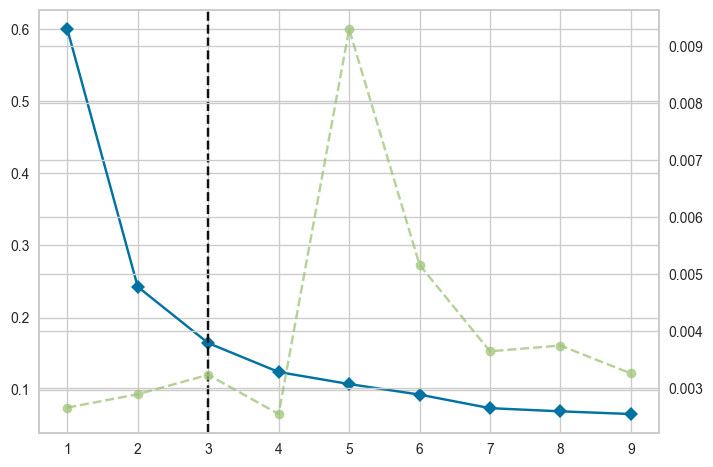

In [90]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,10))
visualizer.fit(hour_mean_pct)

In [104]:
k = 3
model = KMeans(n_clusters = k, random_state = 10) #KMeans 모델을 정의
model.fit(hour_mean_pct) #학습
hour_mean_pct['cluster'] = model.fit_predict(hour_mean_pct).astype(str) #클러스터 열 만들기

In [92]:
k = 3
model = KMeans(n_clusters=k, random_state=10)
hour_mean_pct['cluster'] = model.fit_predict(hour_mean_pct).astype(str)


In [105]:
fig = px.scatter(data_frame = hour_mean_pct[['08시','18시','cluster']].reset_index(), x='08시', y='18시', color='cluster', width=700, height=600, title='시간대별 승차 인원 비중 군집화', hover_name='지하철역')
fig.show()

In [94]:
for i in range(k):
    print(f'cluster {i}')
    print(list(hour_mean_pct.query(f'cluster == "{i}"').index))

cluster 0
['강남', '교대', '뚝섬', '삼성', '서초', '선릉', '성수', '시청', '역삼', '을지로3가', '을지로4가', '을지로입구', '한양대']
cluster 1
['건대입구', '구로디지털단지', '당산', '도림천', '동대문역사문화공원', '문래', '방배', '사당', '신당', '신도림', '신설동', '신촌', '영등포구청', '왕십리', '이대', '잠실', '종합운동장', '충정로', '합정', '홍대입구']
cluster 2
['강변', '구의', '낙성대', '대림', '봉천', '상왕십리', '서울대입구', '신답', '신대방', '신림', '신정네거리', '아현', '양천구청', '용답', '용두', '잠실나루', '잠실새내']


### [5] 지도에 분석 결과를 시각화

-  8시 승차 인원과 18시 승차 인원을 지도에 시각화 해보자

- 지하철역별 위도 경도 데이터 전처리

In [95]:
coordinate = pd.read_csv(r'c:\Users\1\Desktop\데이터분석 공부\ryang_python_practice\part.3\Data\실습5_ 교통 데이터를 활용한 지리 데이터 시각화\서울시 역사마스터 정보.csv', encoding='cp949')
coordinate.head()

,역사_ID,역사명,호선,위도,경도
0,9996,미사,5호선,37.560927,127.193877
1,9995,강일,5호선,37.557490,127.175930
2,4929,김포공항,김포골드라인,37.562360,126.801868
3,4928,고촌,김포골드라인,37.601243,126.770345
4,4927,풍무,김포골드라인,37.612488,126.732387


In [96]:
coordinate = coordinate.query('호선 == "2호선"')
coordinate['역사명'] = [i[0] for i in coordinate['역사명'].str.split('(')]  ## 역이름 괄호 기준 앞에 있는거만 자름
coordinate.rename({'역사명':'지하철역'}, axis=1, inplace=True)
coordinate

,역사_ID,지하철역,호선,위도,경도
708,250,용두,2호선,37.574028,127.038091
709,249,신정네거리,2호선,37.520074,126.852912
710,248,양천구청,2호선,37.512398,126.865819
711,247,도림천,2호선,37.514287,126.882768
712,246,신설동,2호선,37.574747,127.024932
713,245,신답,2호선,37.570040,127.046481
714,244,용답,2호선,37.561904,127.050899
715,243,충정로,2호선,37.559704,126.964378
716,242,아현,2호선,37.557345,126.956141
717,241,이대,2호선,37.556733,126.946013


In [97]:
hour_mean.reset_index()[['지하철역','08시','18시']]

,지하철역,08시,18시
0,강남,64827.731343,343752.835821
1,강변,119168.985075,71631.000000
2,건대입구,94501.731343,89339.671642
3,교대,37022.164179,144218.925373
4,구로디지털단지,182999.328358,223309.611940
5,구의,112258.820896,43149.910448
6,낙성대,125625.074627,52412.388060
7,당산,58876.074627,62581.805970
8,대림,95339.776119,57793.552239
9,도림천,3241.298507,3535.955224


In [98]:
hour_mean_merge = hour_mean.reset_index()[['지하철역','08시','18시']]
coordinate_merge = coordinate[['지하철역','위도','경도']]
hour_mean_coor = pd.merge(hour_mean_merge, coordinate_merge, on='지하철역')

In [99]:
hour_mean_coor['cluster'] = model.fit_predict(hour_mean_pct).astype(str)
hour_mean_coor.head()

,지하철역,08시,18시,위도,경도,cluster
0,강남,64827.731343,343752.835821,37.497990,127.027912,0
1,강변,119168.985075,71631.000000,37.535095,127.094681,2
2,건대입구,94501.731343,89339.671642,37.540373,127.069191,1
3,교대,37022.164179,144218.925373,37.493961,127.014667,0
4,구로디지털단지,182999.328358,223309.611940,37.485266,126.901401,1


- 지도에 시각화

In [ ]:
pip install folium

In [100]:
import folium
from folium import plugins

In [106]:
center = [37.541, 126.986] #서울 중간

m = folium.Map(location=center, zoom_start=12)
m.add_child(plugins.HeatMap(zip(hour_mean_coor['위도'], hour_mean_coor['경도'], hour_mean_coor['08시'])))

m

In [107]:
m = folium.Map(location=center, zoom_start=12)
m.add_child(plugins.HeatMap(zip(hour_mean_coor['위도'], hour_mean_coor['경도'], hour_mean_coor['18시'])))
m

- 승차 인원 유형을 지도에 시각화

In [109]:
m = folium.Map(location=center, zoom_start=12)

for idx in hour_mean_coor.index:
    lat = hour_mean_coor.loc[idx, '위도']
    long = hour_mean_coor.loc[idx, '경도']
    title = hour_mean_coor.loc[idx, '지하철역']

    if hour_mean_coor.loc[idx, 'cluster'] == "0":
        color = '#DF0101'
    elif hour_mean_coor.loc[idx, 'cluster'] == "1":
        color = '#000000'
    else:
        color = '#3A01DF'

    folium.CircleMarker([lat, long]
                        , radius=18
                        , color = color
                        , fill = color
                        , tooltip = title).add_to(m)
m

## **정리**

[1] 승하차 인원이 가장 많은 역은?
- 강남, 잠실, 홍대입구, 신림, 구로디지털단지...

[2] 연도별로 혹은 월별로 승차 인원 추이에 차이가 있는가?
- 코로나가 시작된 2020년, 2021년에 인원이 많이 줄었고 2022년도부터 다시 회복 중

[3] 시간대별로 가장 승차인원이 많은 역은?
- 아침에 비교적 승차 인원이 많은 역과 저녁에 비교적 승차 인원이 많은 역이 있음을 히트맵으로 파악

[4] 지하철역 시간대별 인원 유형 군집화

    cluster 0: 아침과 저녁 승차인원 비율이 비교적 비슷
    ['건대입구', '구로디지털단지', '당산', '도림천', '문래', '방배', '사당', '신당', '신도림', '신설동', '신촌', '영등포구청', '왕십리', '이대', '잠실', '종합운동장', '충정로', '합정', '홍대입구']
    cluster 1: 저녁 승차인원 비율이 높음
    ['강남', '교대', '동대문역사문화공원', '뚝섬', '삼성', '서초', '선릉', '성수', '시청', '역삼', '을지로3가', '을지로4가', '을지로입구', '한양대']
    cluster 2: 아침 승차인원 비율이 높음
    ['강변', '구의', '낙성대', '대림', '봉천', '상왕십리', '서울대입구', '신답', '신대방', '신림', '신정네거리', '아현', '양천구청', '용답', '용두', '잠실나루', '잠실새내']

[5] 지도에 분석 결과를 시각화
- cluster 0: 주거와 상업 시설, 회사가 비슷하게 분포한 지역
- cluster 1: 회사가 많이 분포한 지역
- cluster 2: 주거 지역이 많이 분포한 지역